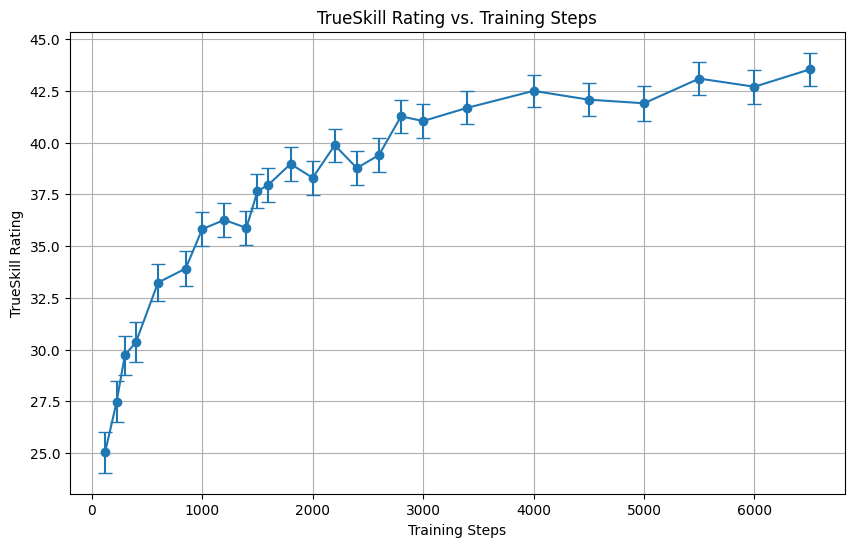

=== Model Rankings (by TrueSkill) ===
Rank  Step count                Rating    Uncertainty  Conservative
-------------------------------------------------------------------
1     6500                      43.54     ±0.81        41.11       
2     6000                      42.70     ±0.82        40.23       
3     5500                      43.09     ±0.81        40.67       
4     5000                      41.90     ±0.84        39.37       
5     4500                      42.08     ±0.81        39.64       
6     4000                      42.50     ±0.79        40.13       
7     3400                      41.68     ±0.80        39.27       
8     3000                      41.04     ±0.81        38.61       
9     2800                      41.27     ±0.80        38.87       
10    2600                      39.40     ±0.81        36.96       
11    2400                      38.77     ±0.81        36.34       
12    2200                      39.88     ±0.80        37.47       
13    2000

In [5]:
import matplotlib.pyplot as plt
import json
import os


os.chdir(r"/media/kyle/Windows/Users/kyleh/git/slippi-ai")

# Load data from JSON file
with open('eval/model_pool_results/trueskill_ratings.json', 'r') as f:
    ratings_data = json.load(f)

data = []
for model_path, values in ratings_data.items():
    # Extract the filename from the full path
    model_name = model_path.split('/')[-1]  # Get the last part of the path
    data.append((model_name, values['mu'], values['sigma']))

data = [(model_name, mu, sigma) for model_name, mu, sigma in data if 'v5' in model_name]

# Extract steps and ratings
steps = [int(name.split('_')[-1].split('.')[0]) if 'v5' in name else 0 for name, _, _ in data]
ratings = [rating for _, rating, _ in data]
uncertainties = [uncertainty for _, _, uncertainty in data]

# Sort by steps
sorted_data = sorted(zip(steps, ratings, uncertainties), key=lambda x: x[0], reverse=True)
sorted_steps, sorted_ratings, sorted_uncertainties = zip(*sorted_data)

# Plotting
plt.figure(figsize=(10, 6))
plt.errorbar(sorted_steps, sorted_ratings, yerr=sorted_uncertainties, fmt='-o', capsize=5)
plt.xlabel("Training Steps")
plt.ylabel("TrueSkill Rating")
plt.title("TrueSkill Rating vs. Training Steps")
plt.grid(True)
#plt.xticks(sorted_steps)
plt.show()

# Create table without v4 entries
print("=== Model Rankings (by TrueSkill) ===")
print("Rank  Step count                Rating    Uncertainty  Conservative")
print("-------------------------------------------------------------------")
for rank, (name, rating, uncertainty) in enumerate(sorted_data, 1):
    conservative = rating - 3 * uncertainty
    print(f"{rank:<5} {name:<25} {rating:<9.2f} ±{uncertainty:<5.2f}       {conservative:<12.2f}")